In [1]:
# importing major libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#
import plotly.express as px

In [2]:
df=pd.read_csv('Magicbricks (1).csv')
df.head()

,Area,BHK,Bathroom,Furnishing,Location,District,Locality,Parking,Status,Transaction,Type,Per_Sqft,Price
0,950.0,2,2.0,Furnished,Karol Bagh,Central Delhi,"DDA MIG Flats Prasad Nagar Phase 2, Prasad Nag...",1.0,Ready_to_move,Resale,Apartment,8761.0,12500000
1,535.0,2,1.0,Furnished,Karol Bagh,Central Delhi,"Dev Nagar, Karol Bagh",1.0,Ready_to_move,New_Property,Apartment,7290.0,3900000
2,1280.0,3,3.0,Furnished,Karol Bagh,Central Delhi,Karol Bagh,2.0,Ready_to_move,Resale,Builder_Floor,14092.0,15000000
3,1135.0,3,3.0,Furnished,Karol Bagh,Central Delhi,"The Amaryllis, Karol Bagh",2.0,Almost_ready,Resale,Apartment,22222.0,25000000
4,1135.0,3,3.0,Furnished,Karol Bagh,Central Delhi,"The Amaryllis, Karol Bagh",2.0,Almost_ready,Resale,Apartment,22222.0,25000000


In [3]:
df.shape

(1214, 13)

In [4]:
df.columns

Index(['Area', 'BHK', 'Bathroom', 'Furnishing', 'Location', 'District',
       'Locality', 'Parking', 'Status', 'Transaction', 'Type', 'Per_Sqft',
       'Price'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1214 entries, 0 to 1213
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1214 non-null   float64
 1   BHK          1214 non-null   int64  
 2   Bathroom     1212 non-null   float64
 3   Furnishing   1214 non-null   object 
 4   Location     1214 non-null   object 
 5   District     1214 non-null   object 
 6   Locality     1214 non-null   object 
 7   Parking      1182 non-null   float64
 8   Status       1214 non-null   object 
 9   Transaction  1214 non-null   object 
 10  Type         1209 non-null   object 
 11  Per_Sqft     973 non-null    float64
 12  Price        1214 non-null   int64  
dtypes: float64(4), int64(2), object(7)
memory usage: 123.4+ KB


In [6]:
df.describe().round()

,Area,BHK,Bathroom,Parking,Per_Sqft,Price
count,1214.0,1214.0,1212.0,1182.0,973.0,1214.0
mean,1452.0,3.0,3.0,2.0,15575.0,20798979.0
std,1586.0,1.0,1.0,6.0,21574.0,25613077.0
min,28.0,1.0,1.0,1.0,1259.0,1000000.0
25%,800.0,2.0,2.0,1.0,6154.0,5600000.0
50%,1150.0,3.0,2.0,1.0,10838.0,14000000.0
75%,1620.0,3.0,3.0,2.0,17647.0,25000000.0
max,24300.0,10.0,7.0,114.0,183333.0,240000000.0


In [7]:
# duplicacy

print('Number of Duplicate entries',df.duplicated().sum())

Number of Duplicate entries 79


In [8]:
# outliers
df.Parking.value_counts()

Parking
1.0      790
2.0      323
3.0       41
4.0       16
5.0        7
114.0      3
9.0        1
10.0       1
Name: count, dtype: int64

In [9]:
# preprocessing done

In [10]:
df.columns

Index(['Area', 'BHK', 'Bathroom', 'Furnishing', 'Location', 'District',
       'Locality', 'Parking', 'Status', 'Transaction', 'Type', 'Per_Sqft',
       'Price'],
      dtype='object')

In [11]:
# univariate analysis
# 2-2 graph
# 1 column-->analysis

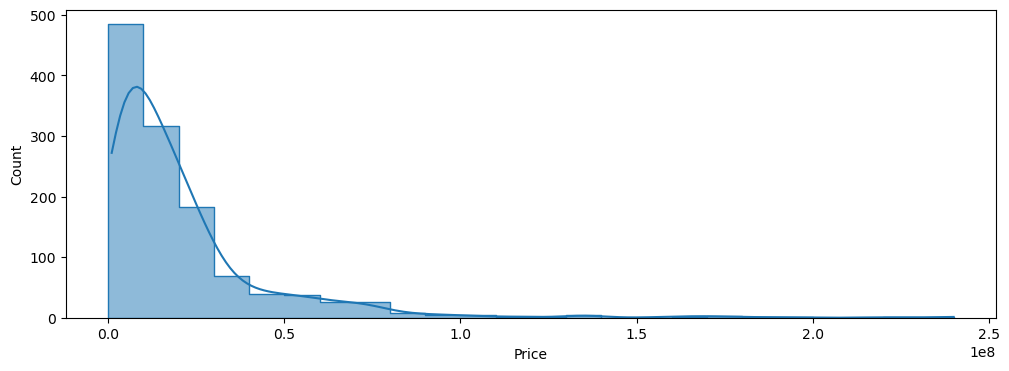

In [12]:
# price 
plt.figure(figsize=(12,4))
sns.histplot(data=df,x='Price',bins=range(0,250000000,10000000),kde=True,element='step')
plt.show()

<Figure size 1200x400 with 0 Axes>

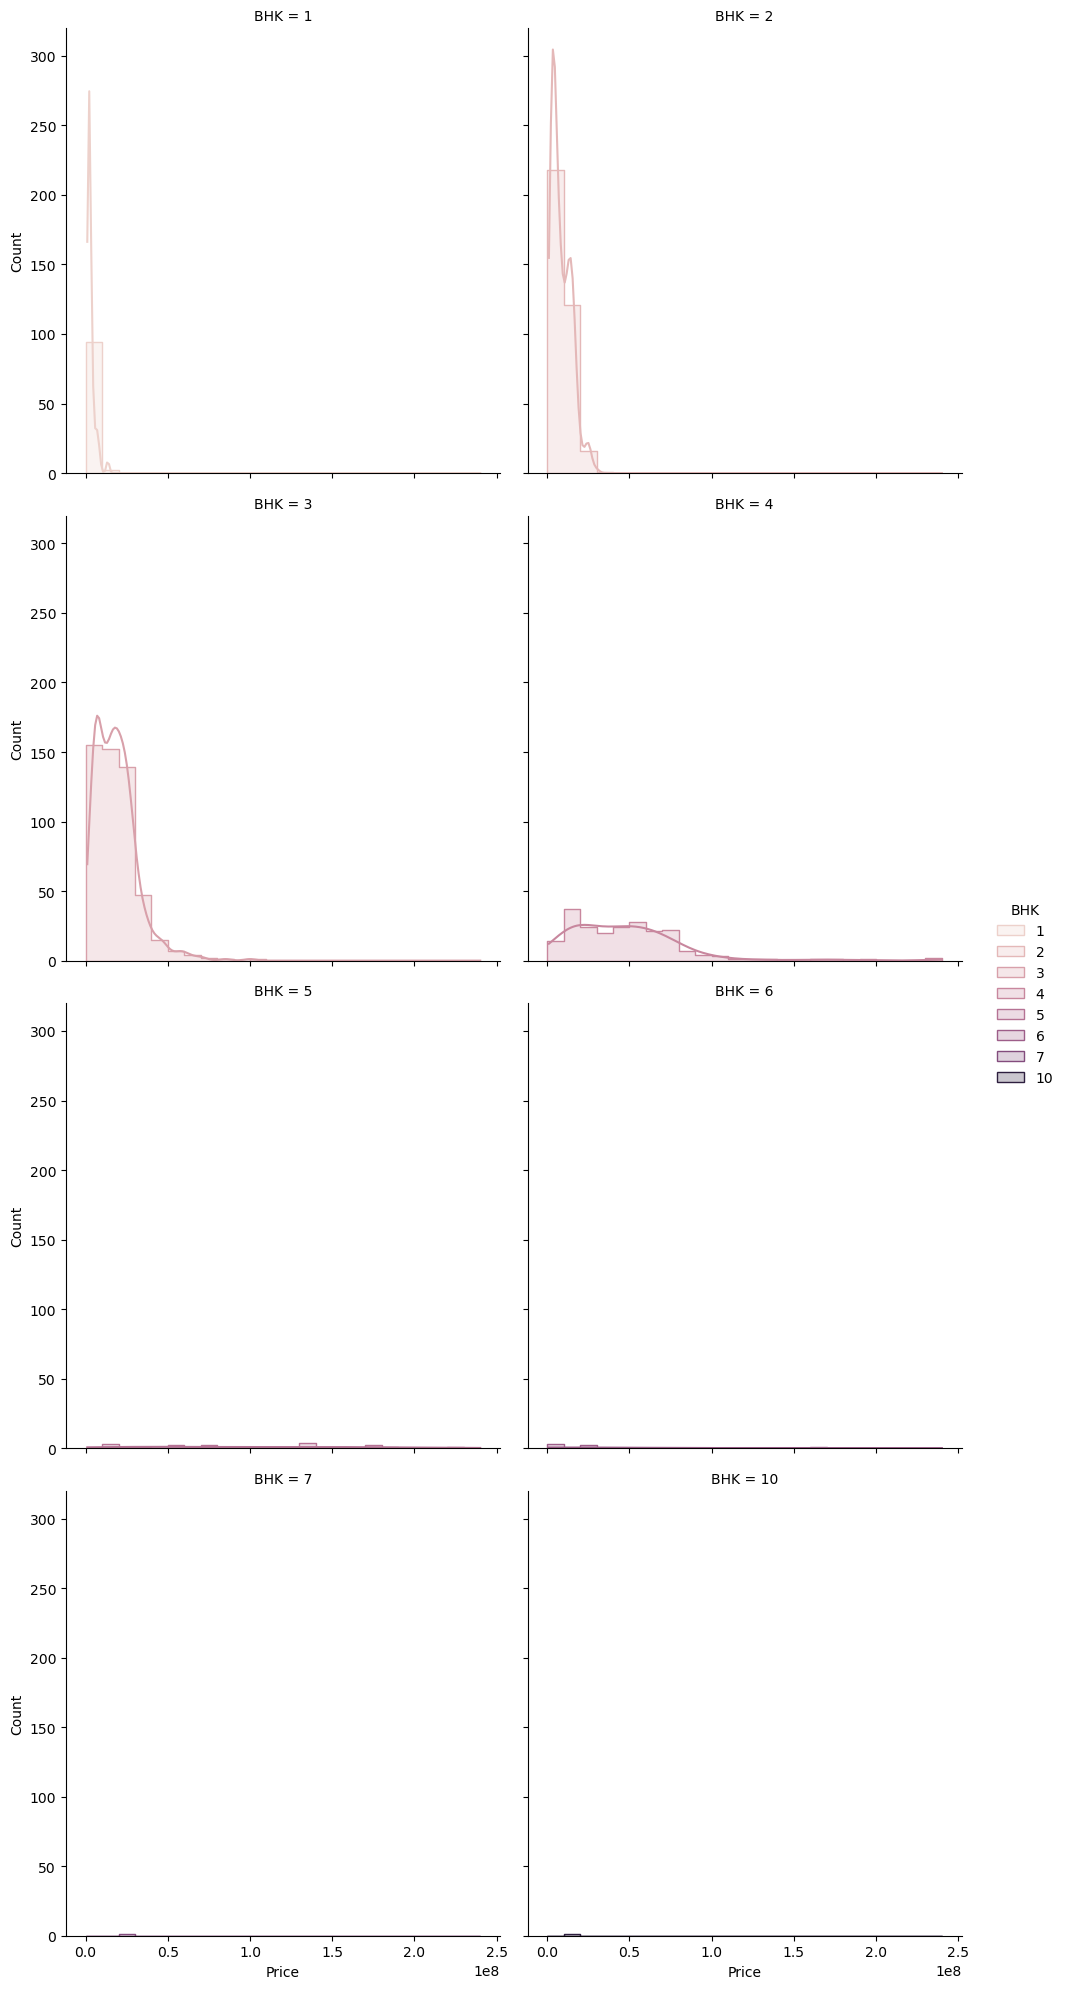

In [13]:
plt.figure(figsize=(12,4))
sns.displot(data=df,x='Price',hue='BHK',col='BHK',col_wrap=2,
bins=range(0,250000000,10000000),kde=True,element='step')
plt.show()

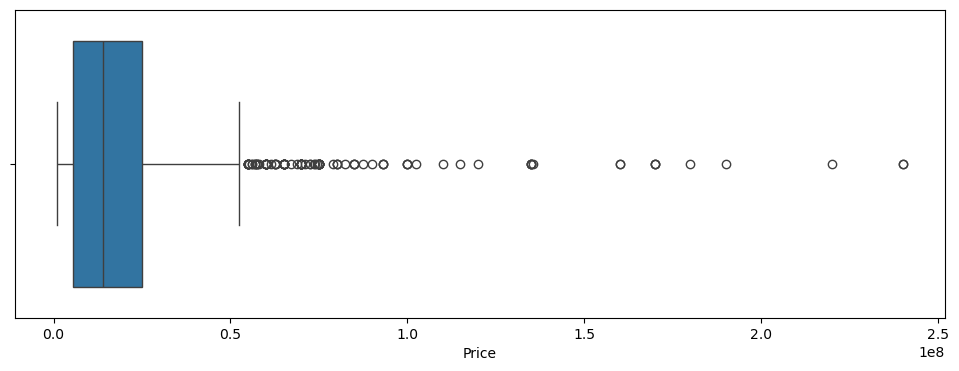

In [14]:
plt.figure(figsize=(12,4))
sns.boxplot(data=df,x='Price')
plt.show()

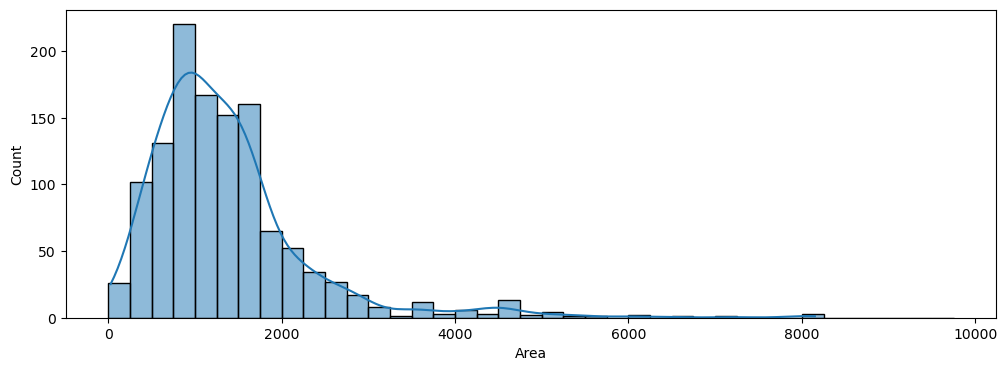

In [15]:
df[df.Area>10000]
df.Area = np.where(df.Area>10000,df.Area/10,df.Area)

df.Area
plt.figure(figsize=(12,4))
sns.histplot(data=df,x='Area',bins=range(0,10000,250),kde=True)
plt.show()


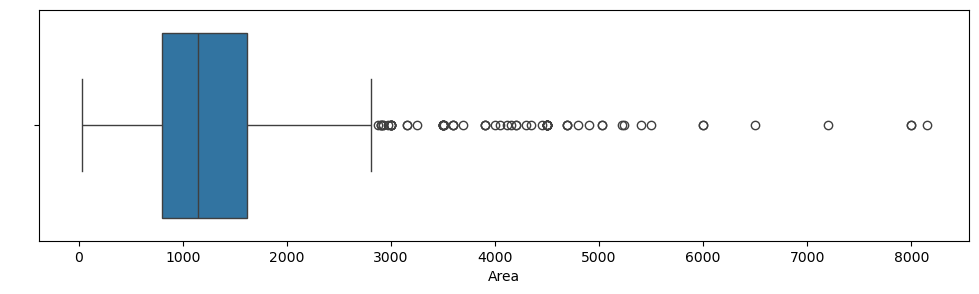

In [16]:
plt.figure(figsize=(12,3))
sns.boxplot(data=df,x='Area')#,bins=range(0,25000,250),kde=True)
plt.ylabel(' ')
plt.show()

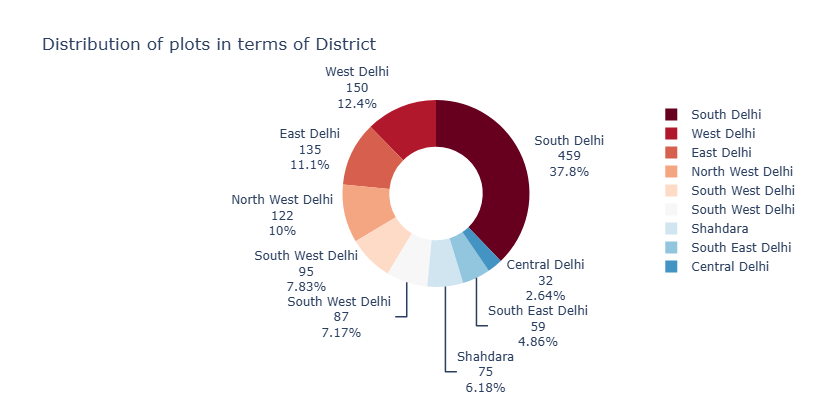

In [17]:
df.columns
import plotly
temp = df.District.value_counts().reset_index()

px.pie(temp,values='count',names='District',hole=0.5,
       color_discrete_sequence=plotly.colors.sequential.RdBu,height=400,
       title='Distribution of plots in terms of District').update_traces(textposition='outside',textinfo='percent+label+value')

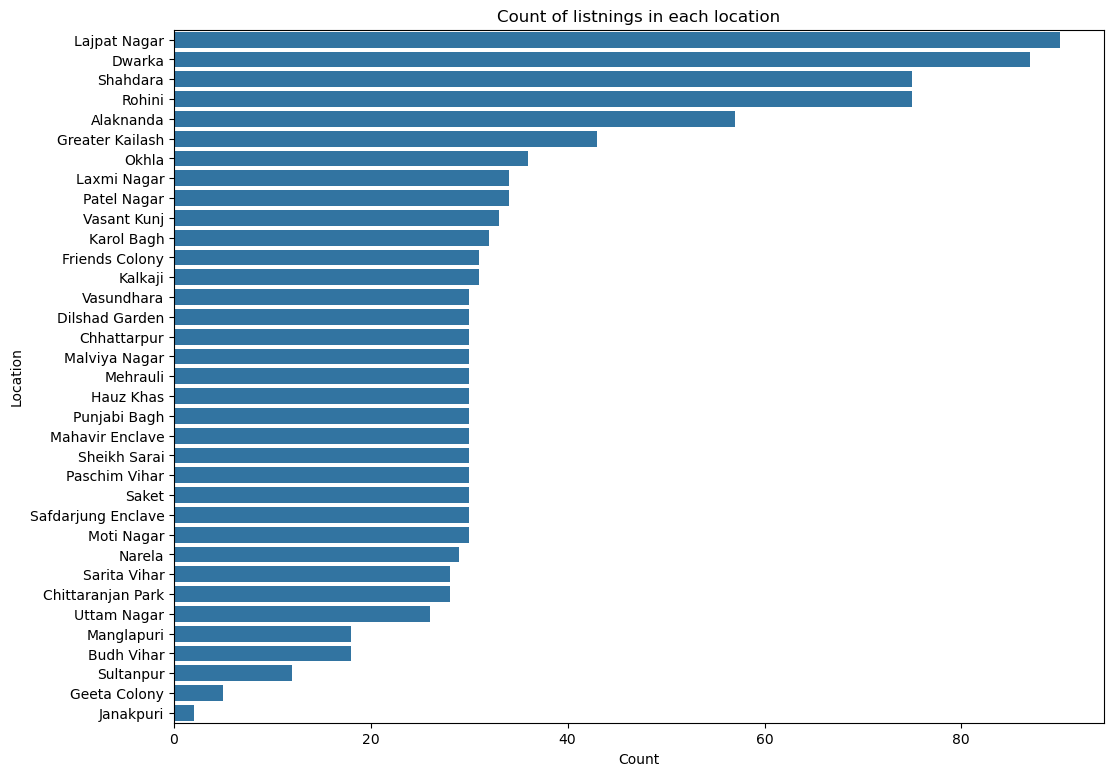

In [18]:
# location

loc_temp = df.Location.value_counts().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12,9))
sns.countplot(data=df,y='Location',order=loc_temp.Location)
plt.title('Count of listnings in each location')
plt.ylabel('Location')
plt.xlabel('Count')
plt.show()

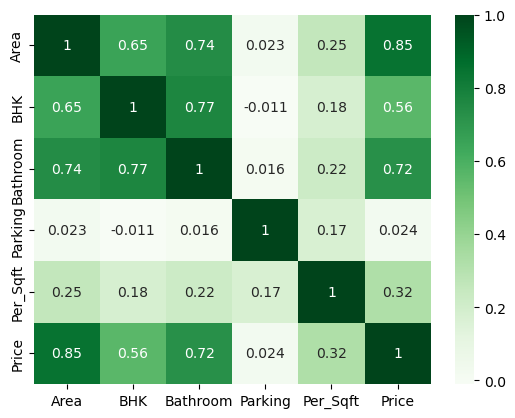

In [19]:
# multivariate analysis
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='Greens')
plt.show()

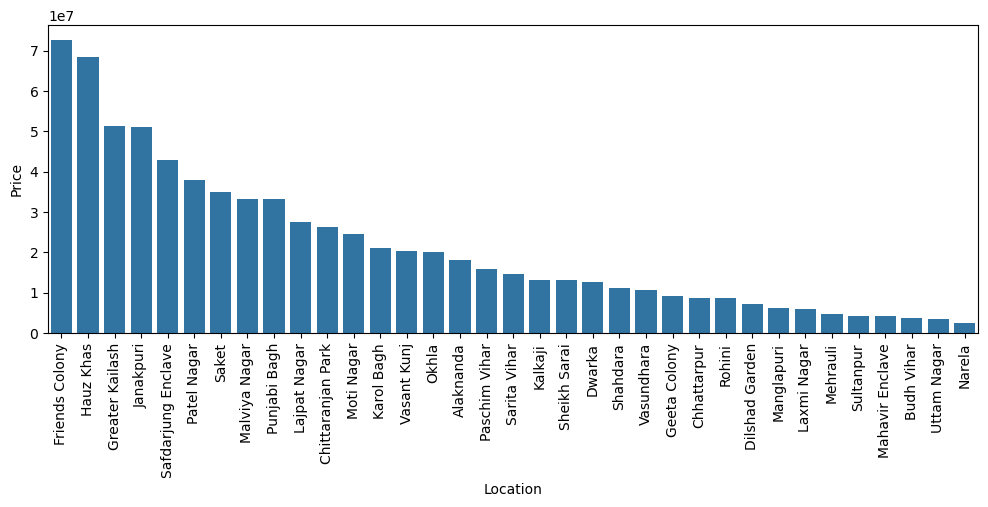

In [20]:
# bivariate analysis

# Location
# Price

loc_temp_price = df.groupby('Location')['Price'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12,4))
sns.barplot(data=df,x='Location',y='Price',ci=False,order=loc_temp_price.Location)
plt.xticks(rotation=90)
plt.show()

In [21]:
df.columns

# bivariate analysis

Index(['Area', 'BHK', 'Bathroom', 'Furnishing', 'Location', 'District',
       'Locality', 'Parking', 'Status', 'Transaction', 'Type', 'Per_Sqft',
       'Price'],
      dtype='object')

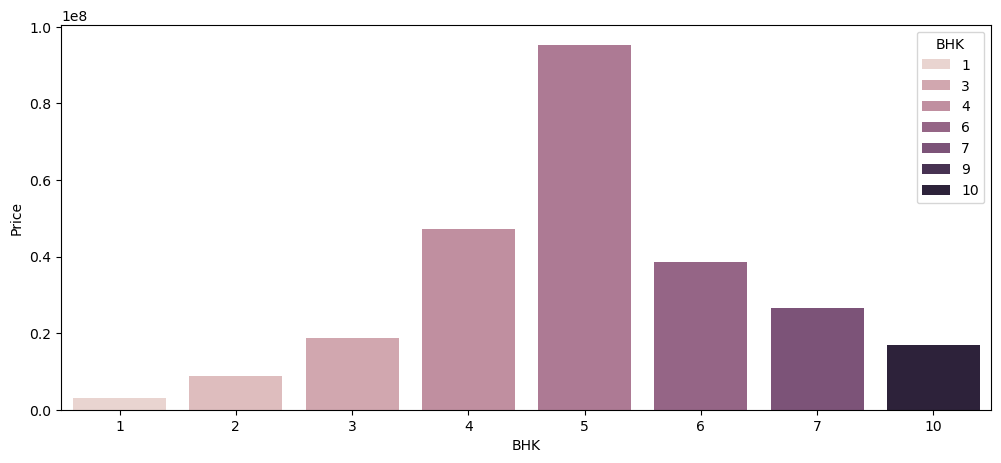

In [22]:
plt.figure(figsize=(12,5))
sns.barplot(data=df,x='BHK',y='Price',hue='BHK',ci=False)
plt.show()

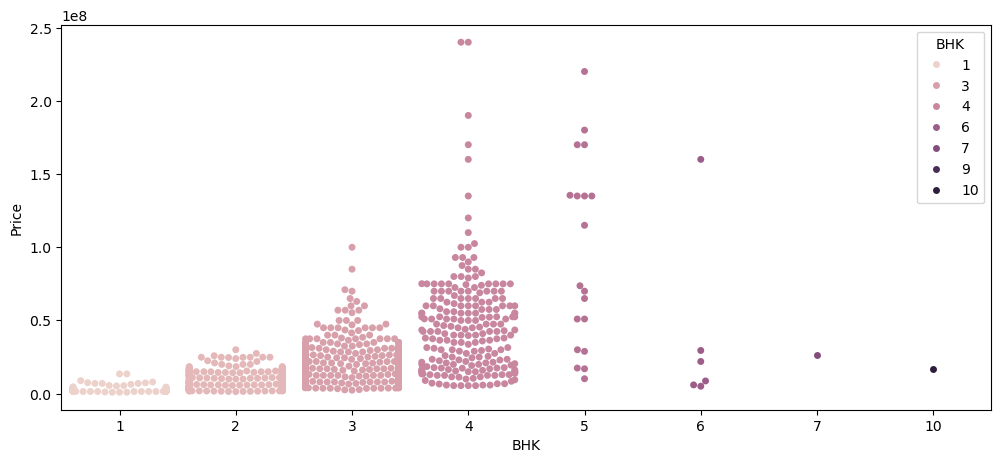

In [23]:
plt.figure(figsize=(12,5))
sns.swarmplot(data=df,x='BHK',y='Price',hue='BHK')
plt.show()

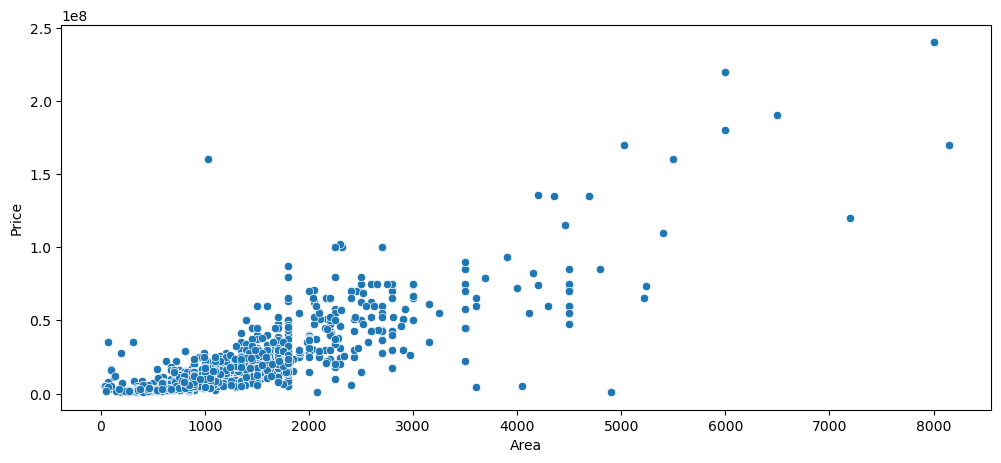

In [24]:
df.columns
plt.figure(figsize=(12,5))
sns.scatterplot(data=df,x='Area',y='Price')
plt.show()

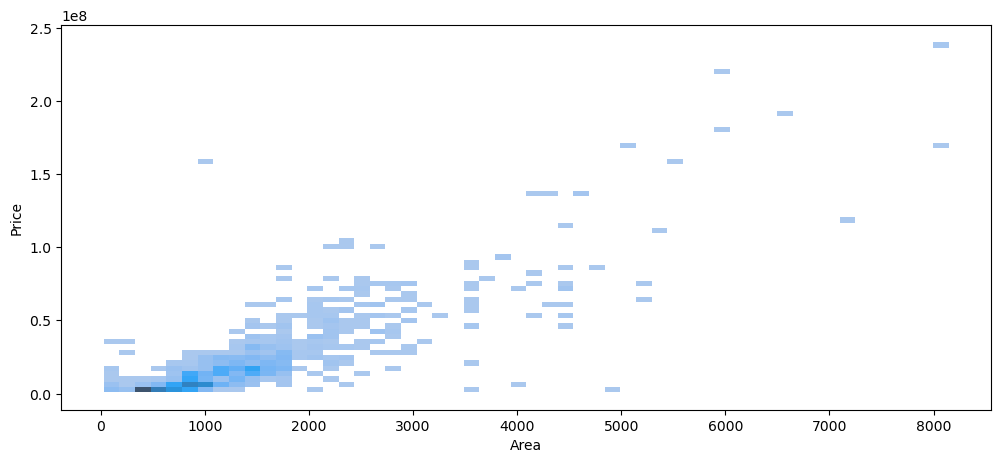

In [25]:
plt.figure(figsize=(12,5))
sns.histplot(data=df,x='Area',y='Price')
plt.show()

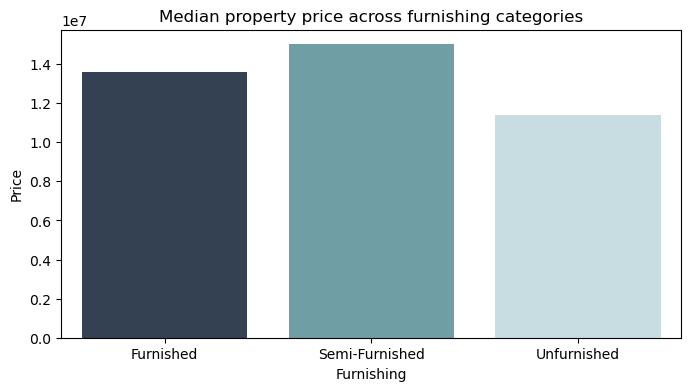

In [29]:
colors = ['#2E4057','#66A5AD','#C4DFE6']
plt.figure(figsize=(8,4))
sns.barplot(data=df,x='Furnishing',y='Price',ci=False,hue='Furnishing',estimator='median',palette=colors)
plt.title('Median property price across furnishing categories')
plt.show()

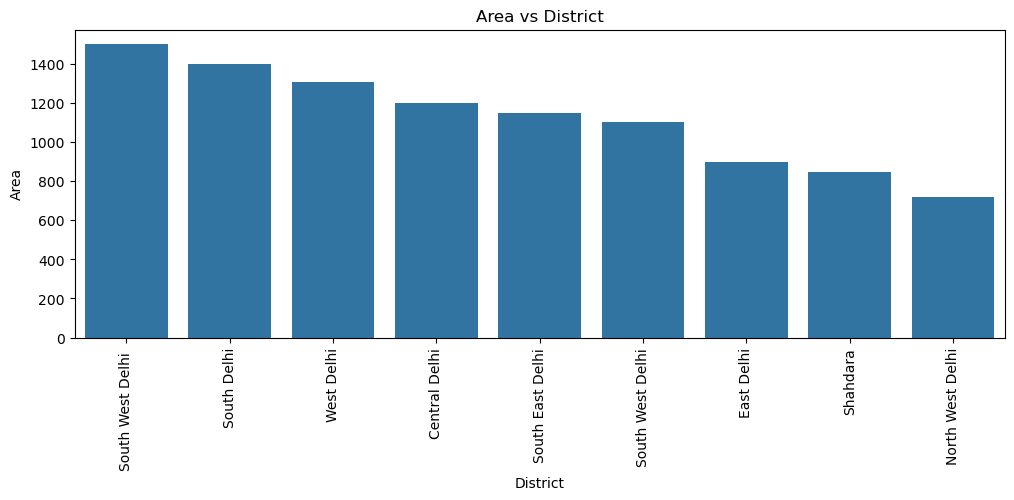

            District    Area
0  South West Delhi   1500.0
1        South Delhi  1400.0
2         West Delhi  1305.0
3      Central Delhi  1200.0
4   South East Delhi  1150.0
5   South West Delhi  1100.0
6         East Delhi   900.0
7           Shahdara   846.0
8   North West Delhi   720.0


In [36]:
temp_district_area = df.groupby('District')['Area'].median().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12,4))
sns.barplot(data=df,x='District',y='Area',order=temp_district_area.District,ci=False,estimator='median')
plt.xticks(rotation=90)
plt.title('Area vs District')
plt.show()
print(temp_district_area)